
# PARP inhibitor-induced nascent strand gap repair: proof-of-concept notebook

This notebook implements a reduced dynamical systems model for **PARP inhibitor-induced nascent strand gap formation** and **BRCA1-BRCA2-RAD51-dependent repair**.

## Biological variables

- **L(t)**: ligatable nascent lagging-strand discontinuities  
- **T(t)**: trapped PARP-DNA complexes  
- **G(t)**: persistent daughter-strand gaps  
- **R(t)**: RAD51 repair intermediates  
- **M(t)**: matured nascent DNA  
- **D(t)**: secondary double-strand breaks  
- **S(t)**: predicted survival  

## Reduced model

$$
\frac{dL}{dt} = \alpha - \eta_{LIG1} k_{lig} L - k_p L
$$

$$
\frac{dT}{dt} = k_{trap}^{max} I_{PARPi} \tau k_p L - \delta_T T
$$

$$
\frac{dG}{dt} = \beta_1 L + \beta_2 T - \gamma \eta_{BRCA1}\eta_{BRCA2} G - \kappa G - \delta_G G
$$

$$
\frac{dR}{dt} = \gamma \eta_{BRCA1}\eta_{BRCA2} G - \rho R - \delta_R R
$$

$$
\frac{dM}{dt} = \eta_{LIG1} k_{lig} L + \rho R
$$

$$
\frac{dD}{dt} = \kappa G - \delta_D D
$$

and the survival function is

$$
S(t) = \exp\left[-\omega_G \int_0^t G(u)\,du - \omega_D \int_0^t D(u)\,du\right]
$$

This is a **conceptual model**, not a parameter-fitted experimental model.


In [2]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130



## Simulator

The function below numerically integrates the reduced ODE system using a simple forward Euler method.


In [5]:

def simulate_condition(
    t_max=72.0,
    dt=0.02,
    alpha=1.0,
    k_lig=0.85,
    k_p=0.55,
    k_trap_max=1.15,
    tau=1.0,
    delta_T=0.22,
    beta1=0.12,
    beta2=0.95,
    gamma=0.42,
    kappa=0.045,
    delta_G=0.03,
    rho=0.33,
    delta_R=0.04,
    delta_D=0.02,
    omega_G=0.0065,
    omega_D=0.06,
    eta_LIG1=1.0,
    eta_BRCA1=1.0,
    eta_BRCA2=1.0,
    I_PARPi=0.0,
    initial_state=None,
):
    n_steps = int(t_max / dt) + 1
    t = np.linspace(0.0, t_max, n_steps)

    L = np.zeros(n_steps)
    T = np.zeros(n_steps)
    G = np.zeros(n_steps)
    R = np.zeros(n_steps)
    M = np.zeros(n_steps)
    D = np.zeros(n_steps)
    S = np.zeros(n_steps)

    area_G = np.zeros(n_steps)
    area_D = np.zeros(n_steps)
    psi = np.zeros(n_steps)

    if initial_state is not None:
        L[0] = float(initial_state.get("L", 0.0))
        T[0] = float(initial_state.get("T", 0.0))
        G[0] = float(initial_state.get("G", 0.0))
        R[0] = float(initial_state.get("R", 0.0))
        M[0] = float(initial_state.get("M", 0.0))
        D[0] = float(initial_state.get("D", 0.0))

    S[0] = 1.0

    repair_capacity = gamma * eta_BRCA1 * eta_BRCA2
    trap_rate = k_trap_max * I_PARPi * tau

    for i in range(1, n_steps):
        L_prev = max(L[i - 1], 0.0)
        T_prev = max(T[i - 1], 0.0)
        G_prev = max(G[i - 1], 0.0)
        R_prev = max(R[i - 1], 0.0)
        M_prev = max(M[i - 1], 0.0)
        D_prev = max(D[i - 1], 0.0)

        dL = alpha - eta_LIG1 * k_lig * L_prev - k_p * L_prev
        dT = trap_rate * k_p * L_prev - delta_T * T_prev
        dG = beta1 * L_prev + beta2 * T_prev - repair_capacity * G_prev - kappa * G_prev - delta_G * G_prev
        dR = repair_capacity * G_prev - rho * R_prev - delta_R * R_prev
        dM = eta_LIG1 * k_lig * L_prev + rho * R_prev
        dD = kappa * G_prev - delta_D * D_prev

        L[i] = max(L_prev + dt * dL, 0.0)
        T[i] = max(T_prev + dt * dT, 0.0)
        G[i] = max(G_prev + dt * dG, 0.0)
        R[i] = max(R_prev + dt * dR, 0.0)
        M[i] = max(M_prev + dt * dM, 0.0)
        D[i] = max(D_prev + dt * dD, 0.0)

        area_G[i] = area_G[i - 1] + 0.5 * dt * (G_prev + G[i])
        area_D[i] = area_D[i - 1] + 0.5 * dt * (D_prev + D[i])

        hazard = omega_G * area_G[i] + omega_D * area_D[i]
        S[i] = math.exp(-hazard)

        numerator = beta1 * L[i] + beta2 * T[i]
        denominator = repair_capacity + kappa + delta_G + 1e-9
        psi[i] = numerator / denominator

    return {
        "t": t,
        "L": L,
        "T": T,
        "G": G,
        "R": R,
        "M": M,
        "D": D,
        "S": S,
        "AUC_G": area_G[-1],
        "AUC_D": area_D[-1],
        "Psi": psi,
        "Psi_final": psi[-1],
        "survival_final": S[-1],
        "gap_peak": float(np.max(G)),
        "dsb_peak": float(np.max(D)),
        "rad51_peak": float(np.max(R)),
        "mature_final": float(M[-1]),
    }


## Run a small condition panel

In [8]:

common = dict(
    t_max=72.0,
    dt=0.02,
    alpha=1.0,
    k_lig=0.85,
    k_p=0.55,
    k_trap_max=1.15,
    delta_T=0.22,
    beta1=0.12,
    beta2=0.95,
    gamma=0.42,
    kappa=0.045,
    delta_G=0.03,
    rho=0.33,
    delta_R=0.04,
    delta_D=0.02,
    omega_G=0.0065,
    omega_D=0.06,
)

results = {
    "WT": simulate_condition(**common, eta_LIG1=1.0, eta_BRCA1=1.0, eta_BRCA2=1.0, I_PARPi=0.0, tau=0.0),
    "WT + PARPi": simulate_condition(**common, eta_LIG1=1.0, eta_BRCA1=1.0, eta_BRCA2=1.0, I_PARPi=1.0, tau=1.0),
    "BRCA2−/− + PARPi": simulate_condition(**common, eta_LIG1=1.0, eta_BRCA1=1.0, eta_BRCA2=0.05, I_PARPi=1.0, tau=1.0),
    "LIG1↓ + PARPi": simulate_condition(**common, eta_LIG1=0.12, eta_BRCA1=1.0, eta_BRCA2=1.0, I_PARPi=1.0, tau=1.0),
    "LIG1↓ BRCA2−/− + PARPi": simulate_condition(**common, eta_LIG1=0.12, eta_BRCA1=1.0, eta_BRCA2=0.05, I_PARPi=1.0, tau=1.0),
    "WT + veliparib-like": simulate_condition(**common, eta_LIG1=1.0, eta_BRCA1=1.0, eta_BRCA2=1.0, I_PARPi=1.0, tau=0.35),
    "WT + talazoparib-like": simulate_condition(**common, eta_LIG1=1.0, eta_BRCA1=1.0, eta_BRCA2=1.0, I_PARPi=1.0, tau=1.75),
}


## Summarize the simulated phenotypes

In [11]:

summary = pd.DataFrame({
    name: {
        "Final survival": res["survival_final"],
        "Peak gap burden": res["gap_peak"],
        "Peak RAD51": res["rad51_peak"],
        "Peak DSB": res["dsb_peak"],
        "Final matured DNA": res["mature_final"],
        "Final Ψ": res["Psi_final"],
        "AUC gaps": res["AUC_G"],
        "AUC DSBs": res["AUC_D"],
    }
    for name, res in results.items()
}).T

summary


,Final survival,Peak gap burden,Peak RAD51,Peak DSB,Final matured DNA,Final Ψ,AUC gaps,AUC DSBs
WT,4.399047e-01,0.173160,0.196560,0.292048,47.598200,0.173160,11.995760,12.387078
WT + PARPi,2.176173e-08,4.114357,4.670349,6.717129,139.157610,4.114357,267.109719,265.114994
BRCA2−/− + PARPi,6.663892e-33,21.175422,1.201068,31.880112,64.672945,21.214654,1199.564665,1104.857233
LIG1↓ + PARPi,7.446490e-17,8.834508,10.028355,14.331063,214.182843,8.834509,566.308980,557.586591
LIG1↓ BRCA2−/− + PARPi,2.844474e-68,45.460926,2.578385,67.882448,56.261211,45.552937,2538.504565,2317.168808
WT + veliparib-like,1.220045e-03,1.552579,1.762386,2.540827,79.643994,1.552579,101.285645,100.841849
WT + talazoparib-like,7.218460e-14,7.070254,8.025691,11.535940,207.827168,7.070255,458.445188,454.660932



## Plotting helpers


In [14]:

def plot_timecourses(results_dict, variable, ylabel, title):
    plt.figure(figsize=(8, 5))
    for name, res in results_dict.items():
        plt.plot(res["t"], res[variable], label=name)
    plt.xlabel("Time, arbitrary units")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_summary_bars(results_dict, metric, ylabel, title):
    names = list(results_dict.keys())
    vals = [results_dict[name][metric] for name in names]
    plt.figure(figsize=(8, 5))
    x = np.arange(len(names))
    plt.bar(x, vals)
    plt.xticks(x, names, rotation=25, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Core mechanistic time courses

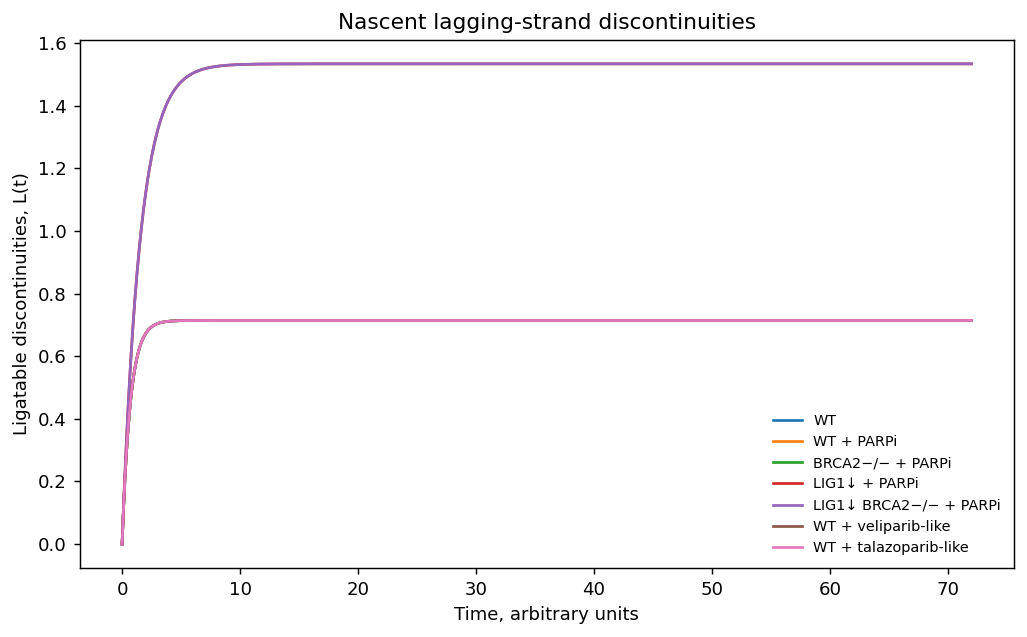

In [17]:
plot_timecourses(results, "L", "Ligatable discontinuities, L(t)", "Nascent lagging-strand discontinuities")

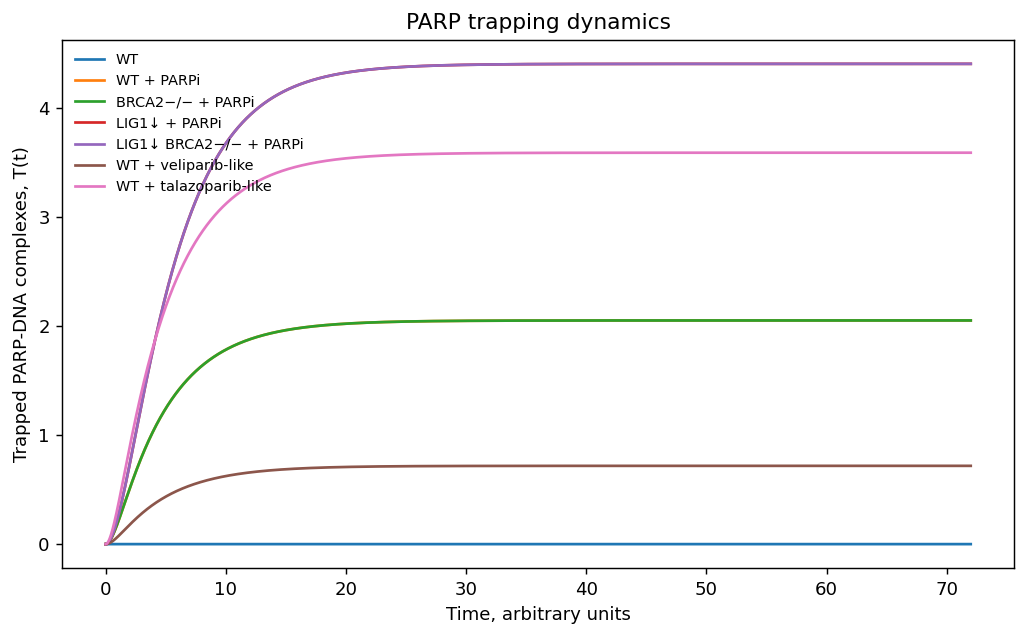

In [19]:
plot_timecourses(results, "T", "Trapped PARP-DNA complexes, T(t)", "PARP trapping dynamics")

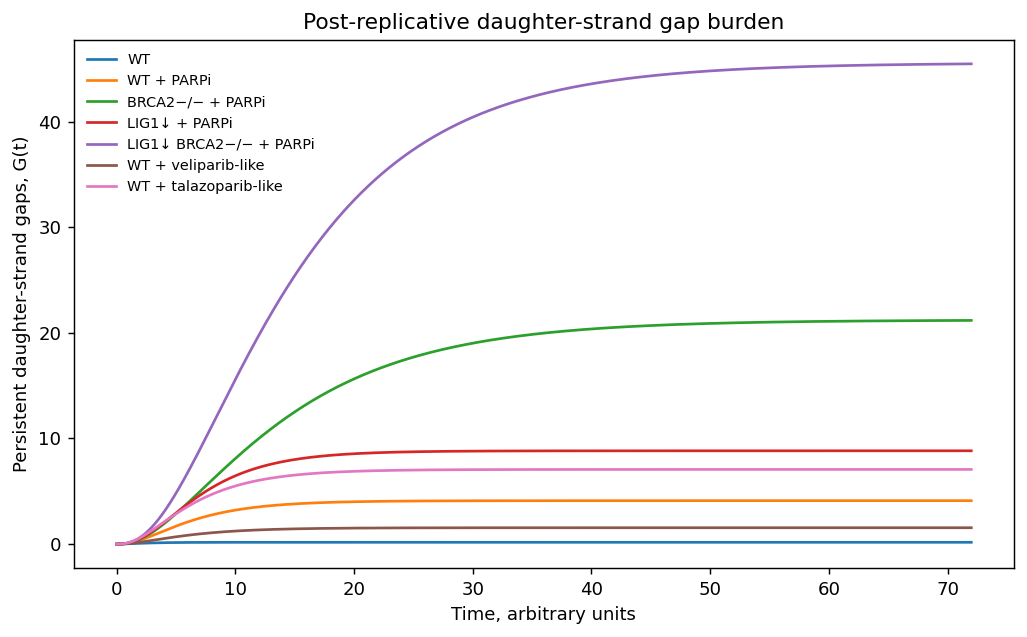

In [21]:
plot_timecourses(results, "G", "Persistent daughter-strand gaps, G(t)", "Post-replicative daughter-strand gap burden")

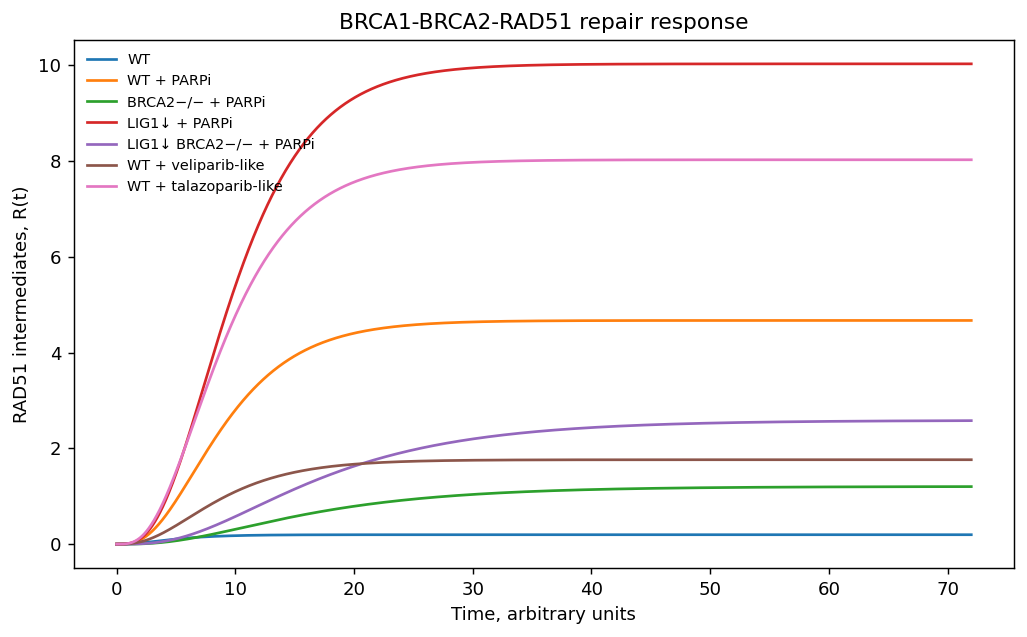

In [23]:
plot_timecourses(results, "R", "RAD51 intermediates, R(t)", "BRCA1-BRCA2-RAD51 repair response")

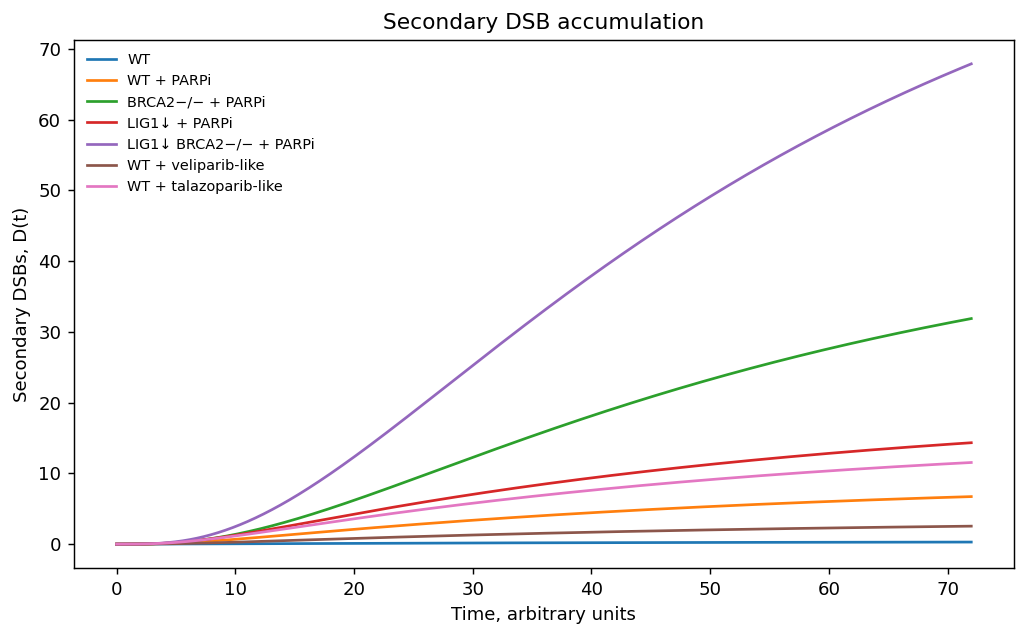

In [25]:
plot_timecourses(results, "D", "Secondary DSBs, D(t)", "Secondary DSB accumulation")

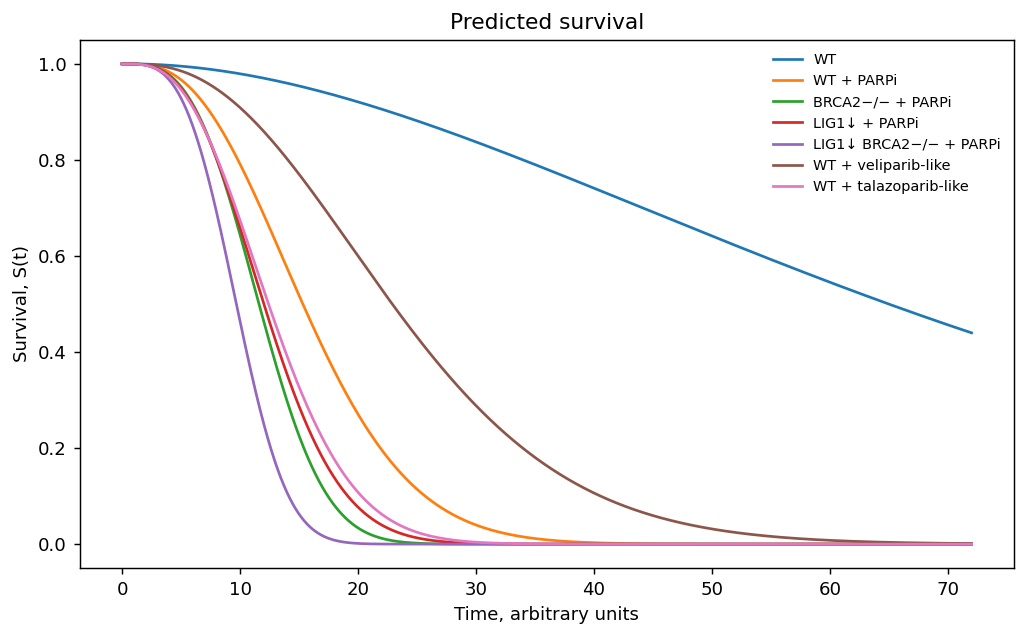

In [27]:
plot_timecourses(results, "S", "Survival, S(t)", "Predicted survival")

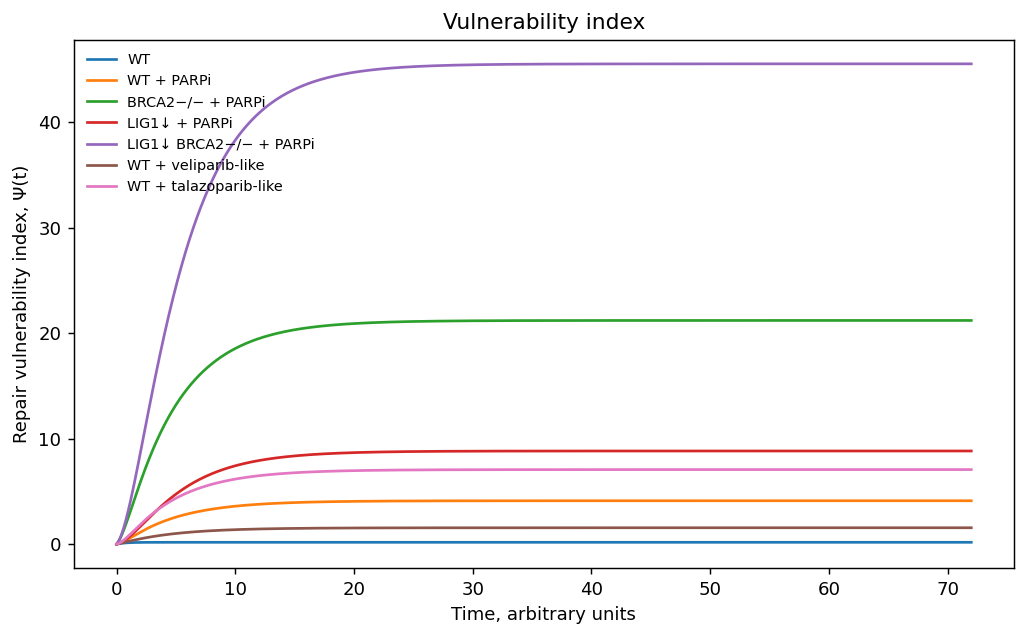

In [29]:
plot_timecourses(results, "Psi", "Repair vulnerability index, Ψ(t)", "Vulnerability index")

## Condition-level summaries

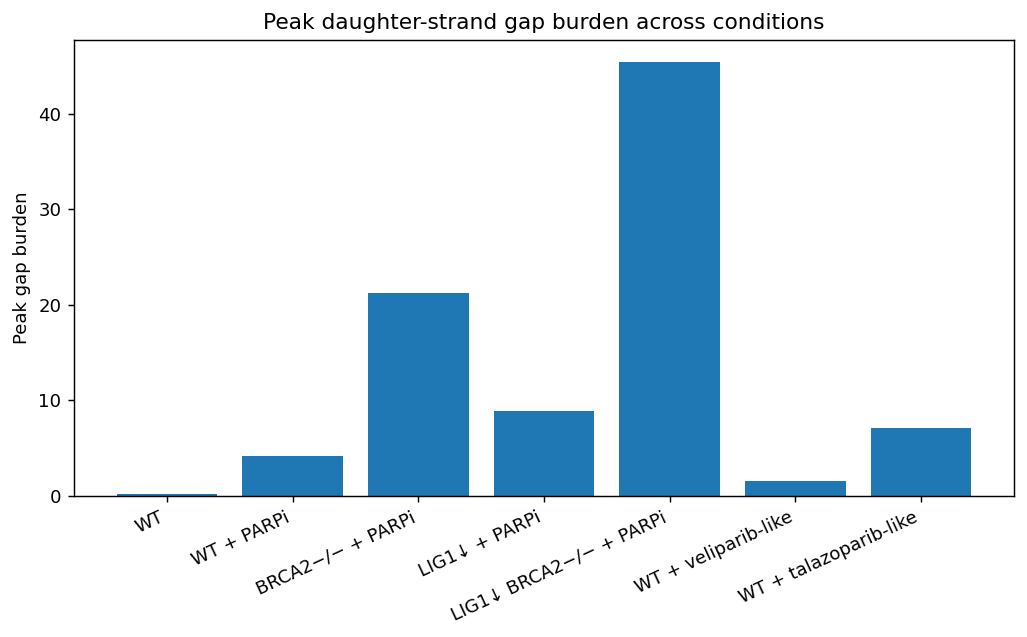

In [32]:
plot_summary_bars(results, "gap_peak", "Peak gap burden", "Peak daughter-strand gap burden across conditions")

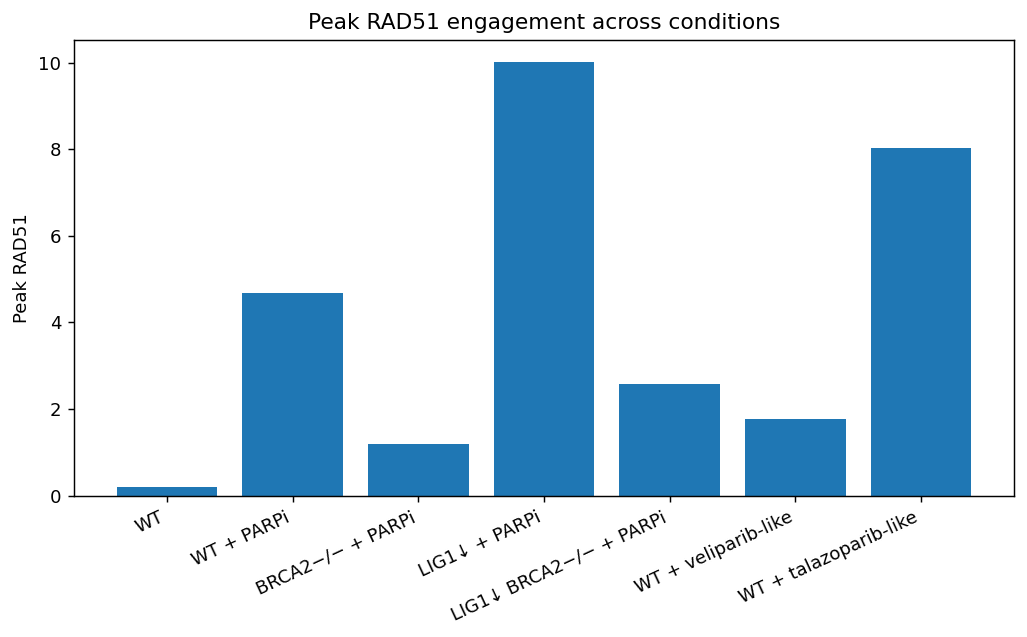

In [34]:
plot_summary_bars(results, "rad51_peak", "Peak RAD51", "Peak RAD51 engagement across conditions")

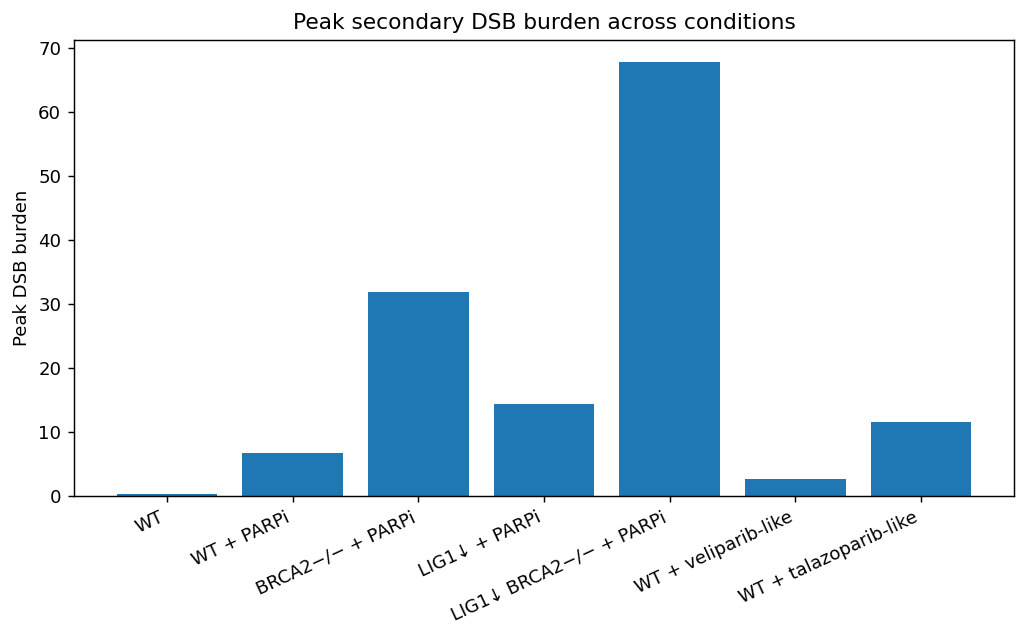

In [36]:
plot_summary_bars(results, "dsb_peak", "Peak DSB burden", "Peak secondary DSB burden across conditions")

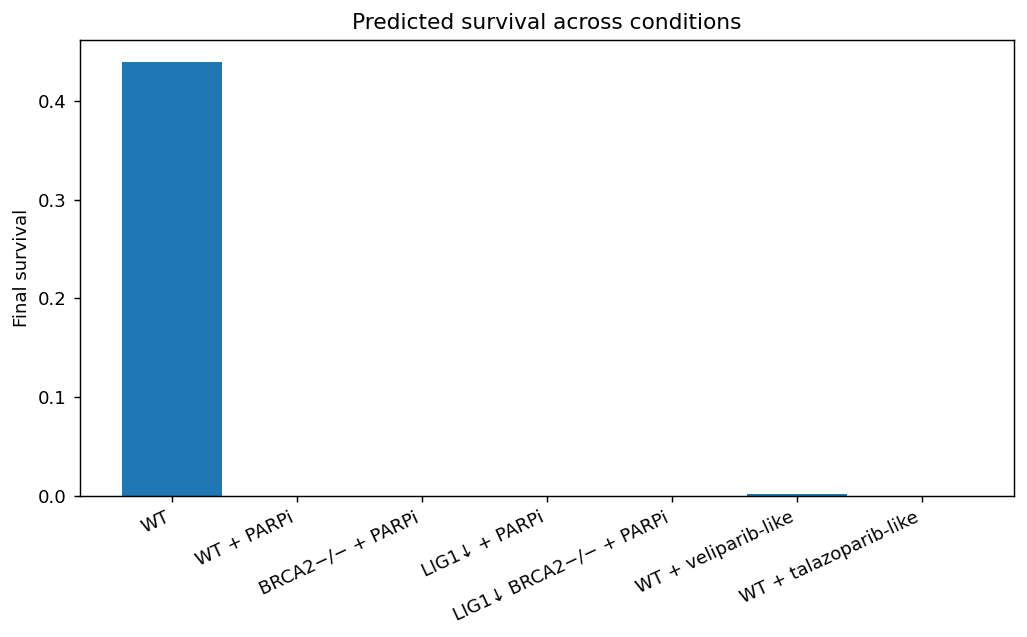

In [38]:
plot_summary_bars(results, "survival_final", "Final survival", "Predicted survival across conditions")

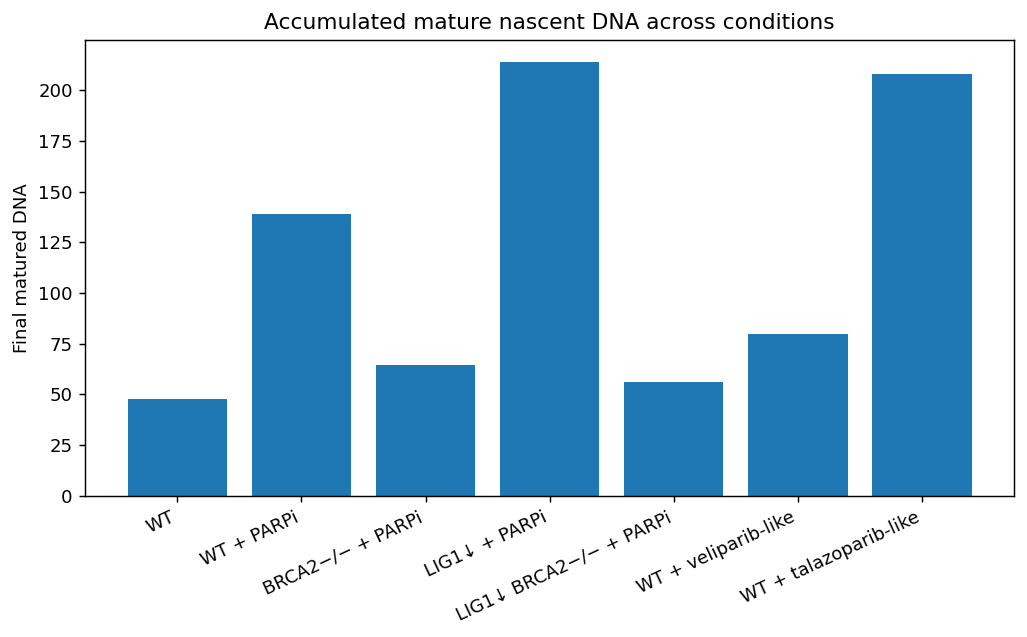

In [40]:
plot_summary_bars(results, "mature_final", "Final matured DNA", "Accumulated mature nascent DNA across conditions")


## Interpretation guide

Expected qualitative behavior of the proof of concept:

- **WT** should keep low gap burden and high survival.
- **WT + PARPi** should increase PARP trapping and daughter-strand gaps, but retain substantial rescue through BRCA1-BRCA2-RAD51.
- **BRCA2−/− + PARPi** should show higher persistent gap burden, weaker RAD51 repair output, higher secondary DSB burden, and lower survival.
- **LIG1↓ + PARPi** should show strong synthetic stress because canonical ligation is impaired while PARP-dependent backup maturation is also compromised by trapping.
- **LIG1↓ BRCA2−/− + PARPi** should show the most severe phenotype.
- **Veliparib-like vs talazoparib-like** conditions should mainly separate according to trapping strength, represented here by **τ**.

## Suggested extensions

You can extend this notebook by adding:

1. Parameter sweeps over **I_PARPi**, **η_BRCA2**, or **η_LIG1**  
2. Sensitivity analysis for **β₂**, **γ**, or **κ**  
3. Stochastic lesion formation instead of deterministic inflow  
4. Explicit fork-proximal and fork-distal compartments  
5. Fitting to comet assay, DNA combing, or RAD51 foci datasets



## Extension 1. PubMed-anchored benchmark assumptions for synthetic assay generation

The extensions below add parameter sweeps, sensitivity analysis, stochastic lesion formation, explicit fork-proximal and fork-distal compartments, and parameter fitting to synthetic assay-like datasets.

These additions are **conceptually benchmarked** to qualitative findings from peer-reviewed journals indexed in PubMed:

- **Hanzlikova et al., 2018, Molecular Cell**: PARP acts as a sensor of unligated Okazaki fragments during DNA replication.
- **Murai et al., 2012, Cancer Research**: clinical PARP inhibitors differ in trapping potency, with stronger trapping generally producing more toxic PARP-DNA complexes.
- **Vaitsiankova et al., 2022, Nature Structural & Molecular Biology**: PARP inhibition impedes maturation of nascent DNA strands and increases post-replicative single-strand gaps.
- **Cong et al., 2021, Molecular Cell**: replication gaps are a major determinant of PARP inhibitor sensitivity in BRCA-deficient settings.

In this notebook, those studies are used to anchor **relative behavior** rather than exact fitted biochemical units. The synthetic assay generators below therefore aim to reproduce the expected ordering of phenotypes, not exact experimental values.



## Extension 2. Utility functions for sweeps, stochastic simulation, assay emulation, and fitting


In [71]:

import itertools
import random

def summarize_condition(res):
    return {
        "gap_peak": res["gap_peak"],
        "rad51_peak": res["rad51_peak"],
        "dsb_peak": res["dsb_peak"],
        "survival_final": res["survival_final"],
        "mature_final": res["mature_final"],
        "AUC_G": res["AUC_G"],
        "AUC_D": res["AUC_D"],
        "Psi_final": res["Psi_final"],
    }


def sweep_parameter(param_name, values, base_kwargs):
    rows = []
    for val in values:
        kwargs = dict(base_kwargs)
        kwargs[param_name] = float(val)
        res = simulate_condition(**kwargs)
        row = {"parameter": param_name, "value": float(val)}
        row.update(summarize_condition(res))
        rows.append(row)
    return pd.DataFrame(rows)


def sweep_two_parameters(param_x, values_x, param_y, values_y, base_kwargs, metric="gap_peak"):
    grid = np.zeros((len(values_y), len(values_x)))
    for iy, vy in enumerate(values_y):
        for ix, vx in enumerate(values_x):
            kwargs = dict(base_kwargs)
            kwargs[param_x] = float(vx)
            kwargs[param_y] = float(vy)
            res = simulate_condition(**kwargs)
            grid[iy, ix] = res[metric]
    return grid


def plot_heatmap(grid, x_values, y_values, x_label, y_label, title, colorbar_label):
    plt.figure(figsize=(7, 5))
    im = plt.imshow(
        grid,
        aspect="auto",
        origin="lower",
        extent=[min(x_values), max(x_values), min(y_values), max(y_values)],
    )
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    cbar = plt.colorbar(im)
    cbar.set_label(colorbar_label)
    plt.tight_layout()
    plt.show()


def local_sensitivity(base_kwargs, param_names=("beta2", "gamma", "kappa"), delta_frac=0.25, metric="gap_peak"):
    baseline = simulate_condition(**base_kwargs)[metric]
    rows = []
    for p in param_names:
        p0 = base_kwargs[p]
        for sign, label in [(-1, "down"), (1, "up")]:
            kwargs = dict(base_kwargs)
            kwargs[p] = p0 * (1.0 + sign * delta_frac)
            res = simulate_condition(**kwargs)
            rows.append({
                "parameter": p,
                "direction": label,
                "value": kwargs[p],
                "metric": metric,
                "baseline": baseline,
                "new_value": res[metric],
                "delta": res[metric] - baseline,
                "relative_delta": (res[metric] - baseline) / baseline if baseline != 0 else np.nan,
            })
    return pd.DataFrame(rows)


def plot_tornado(df, title):
    plot_df = df.copy()
    plot_df["label"] = plot_df["parameter"] + " (" + plot_df["direction"] + ")"
    plot_df = plot_df.sort_values("delta")
    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["label"], plot_df["delta"])
    plt.xlabel("Change in metric")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def simulate_condition_stochastic(
    t_max=72.0,
    dt=0.02,
    alpha_mean=1.0,
    alpha_noise=0.25,
    seed=42,
    **kwargs
):
    rng = np.random.default_rng(seed)
    n_steps = int(t_max / dt) + 1
    t = np.linspace(0.0, t_max, n_steps)

    base = dict(kwargs)
    # defaults reused from deterministic simulator
    alpha = alpha_mean
    k_lig = base.get("k_lig", 0.85)
    k_p = base.get("k_p", 0.55)
    k_trap_max = base.get("k_trap_max", 1.15)
    tau = base.get("tau", 1.0)
    delta_T = base.get("delta_T", 0.22)
    beta1 = base.get("beta1", 0.12)
    beta2 = base.get("beta2", 0.95)
    gamma = base.get("gamma", 0.42)
    kappa = base.get("kappa", 0.045)
    delta_G = base.get("delta_G", 0.03)
    rho = base.get("rho", 0.33)
    delta_R = base.get("delta_R", 0.04)
    delta_D = base.get("delta_D", 0.02)
    omega_G = base.get("omega_G", 0.0065)
    omega_D = base.get("omega_D", 0.06)
    eta_LIG1 = base.get("eta_LIG1", 1.0)
    eta_BRCA1 = base.get("eta_BRCA1", 1.0)
    eta_BRCA2 = base.get("eta_BRCA2", 1.0)
    I_PARPi = base.get("I_PARPi", 0.0)

    L = np.zeros(n_steps)
    T = np.zeros(n_steps)
    G = np.zeros(n_steps)
    R = np.zeros(n_steps)
    M = np.zeros(n_steps)
    D = np.zeros(n_steps)
    S = np.zeros(n_steps)
    area_G = np.zeros(n_steps)
    area_D = np.zeros(n_steps)
    psi = np.zeros(n_steps)
    alpha_series = np.zeros(n_steps)

    S[0] = 1.0
    repair_capacity = gamma * eta_BRCA1 * eta_BRCA2
    trap_rate = k_trap_max * I_PARPi * tau

    for i in range(1, n_steps):
        # Poisson-like or Gaussian lesion inflow around alpha_mean
        alpha_t = max(rng.normal(alpha_mean, alpha_noise), 0.0)
        alpha_series[i] = alpha_t

        L_prev = max(L[i - 1], 0.0)
        T_prev = max(T[i - 1], 0.0)
        G_prev = max(G[i - 1], 0.0)
        R_prev = max(R[i - 1], 0.0)
        M_prev = max(M[i - 1], 0.0)
        D_prev = max(D[i - 1], 0.0)

        dL = alpha_t - eta_LIG1 * k_lig * L_prev - k_p * L_prev
        dT = trap_rate * k_p * L_prev - delta_T * T_prev
        dG = beta1 * L_prev + beta2 * T_prev - repair_capacity * G_prev - kappa * G_prev - delta_G * G_prev
        dR = repair_capacity * G_prev - rho * R_prev - delta_R * R_prev
        dM = eta_LIG1 * k_lig * L_prev + rho * R_prev
        dD = kappa * G_prev - delta_D * D_prev

        L[i] = max(L_prev + dt * dL, 0.0)
        T[i] = max(T_prev + dt * dT, 0.0)
        G[i] = max(G_prev + dt * dG, 0.0)
        R[i] = max(R_prev + dt * dR, 0.0)
        M[i] = max(M_prev + dt * dM, 0.0)
        D[i] = max(D_prev + dt * dD, 0.0)

        area_G[i] = area_G[i - 1] + 0.5 * dt * (G_prev + G[i])
        area_D[i] = area_D[i - 1] + 0.5 * dt * (D_prev + D[i])

        hazard = omega_G * area_G[i] + omega_D * area_D[i]
        S[i] = np.exp(-hazard)

        numerator = beta1 * L[i] + beta2 * T[i]
        denominator = repair_capacity + kappa + delta_G + 1e-9
        psi[i] = numerator / denominator

    return {
        "t": t,
        "alpha_series": alpha_series,
        "L": L, "T": T, "G": G, "R": R, "M": M, "D": D, "S": S,
        "AUC_G": area_G[-1], "AUC_D": area_D[-1], "Psi": psi,
        "Psi_final": psi[-1], "survival_final": S[-1],
        "gap_peak": float(np.max(G)), "dsb_peak": float(np.max(D)),
        "rad51_peak": float(np.max(R)), "mature_final": float(M[-1]),
    }


def simulate_condition_compartmental(
    t_max=72.0,
    dt=0.02,
    alpha_p=1.0,
    transfer_L=0.22,
    transfer_G=0.12,
    eta_LIG1=1.0,
    eta_BRCA1=1.0,
    eta_BRCA2=1.0,
    I_PARPi=0.0,
    k_lig=0.85,
    k_p=0.55,
    k_trap_max=1.15,
    tau=1.0,
    delta_T=0.22,
    beta1=0.12,
    beta2=0.95,
    gamma=0.42,
    kappa=0.045,
    delta_G=0.03,
    rho=0.33,
    delta_R=0.04,
    delta_D=0.02,
    omega_G=0.0065,
    omega_D=0.06,
):
    n_steps = int(t_max / dt) + 1
    t = np.linspace(0.0, t_max, n_steps)

    names = ["Lp","Tp","Gp","Rp","Mp","Dp","Ld","Td","Gd","Rd","Md","Dd"]
    state = {k: np.zeros(n_steps) for k in names}
    S = np.zeros(n_steps)
    area_G = np.zeros(n_steps)
    area_D = np.zeros(n_steps)
    S[0] = 1.0

    repair_capacity = gamma * eta_BRCA1 * eta_BRCA2
    trap_rate = k_trap_max * I_PARPi * tau

    for i in range(1, n_steps):
        Lp,Tp,Gp,Rp,Mp,Dp,Ld,Td,Gd,Rd,Md,Dd = [state[k][i-1] for k in names]

        dLp = alpha_p - eta_LIG1 * k_lig * Lp - k_p * Lp - transfer_L * Lp
        dTp = trap_rate * k_p * Lp - delta_T * Tp
        dGp = beta1 * Lp + beta2 * Tp - repair_capacity * Gp - kappa * Gp - delta_G * Gp - transfer_G * Gp
        dRp = repair_capacity * Gp - rho * Rp - delta_R * Rp
        dMp = eta_LIG1 * k_lig * Lp + rho * Rp
        dDp = kappa * Gp - delta_D * Dp

        dLd = transfer_L * Lp - eta_LIG1 * k_lig * Ld - k_p * Ld
        dTd = trap_rate * k_p * Ld - delta_T * Td
        dGd = transfer_G * Gp + beta1 * Ld + beta2 * Td - repair_capacity * Gd - kappa * Gd - delta_G * Gd
        dRd = repair_capacity * Gd - rho * Rd - delta_R * Rd
        dMd = eta_LIG1 * k_lig * Ld + rho * Rd
        dDd = kappa * Gd - delta_D * Dd

        derivs = [dLp,dTp,dGp,dRp,dMp,dDp,dLd,dTd,dGd,dRd,dMd,dDd]
        for k, prev, d in zip(names, [Lp,Tp,Gp,Rp,Mp,Dp,Ld,Td,Gd,Rd,Md,Dd], derivs):
            state[k][i] = max(prev + dt * d, 0.0)

        G_total = state["Gp"][i] + state["Gd"][i]
        D_total = state["Dp"][i] + state["Dd"][i]
        area_G[i] = area_G[i-1] + 0.5 * dt * ((Gp + Gd) + G_total)
        area_D[i] = area_D[i-1] + 0.5 * dt * ((Dp + Dd) + D_total)
        S[i] = np.exp(-(omega_G * area_G[i] + omega_D * area_D[i]))

    out = {"t": t, **state, "S": S, "AUC_G": area_G[-1], "AUC_D": area_D[-1]}
    out["G_total"] = out["Gp"] + out["Gd"]
    out["D_total"] = out["Dp"] + out["Dd"]
    out["R_total"] = out["Rp"] + out["Rd"]
    return out


def generate_synthetic_assay_dataset(base_kwargs, times, noise_frac=0.08, seed=123):
    rng = np.random.default_rng(seed)

    sim_kwargs = dict(base_kwargs)
    sim_kwargs.pop("t_max", None)
    sim_kwargs.pop("dt", None)

    res = simulate_condition(
        **sim_kwargs,
        t_max=max(times) + 1.0,
        dt=0.02,
    )

    comet = []
    combing_shortening = []
    rad51_foci = []

    for t in times:
        idx = np.argmin(np.abs(res["t"] - t))
        G = res["G"][idx]
        D = res["D"][idx]
        R = res["R"][idx]

        comet_val = 1.0 + 0.7 * G + 0.15 * D
        combing_val = 25.0 - 1.2 * G
        rad51_val = 5.0 + 8.5 * R

        comet.append(comet_val * (1 + rng.normal(0, noise_frac)))
        combing_shortening.append(combing_val * (1 + rng.normal(0, noise_frac)))
        rad51_foci.append(rad51_val * (1 + rng.normal(0, noise_frac)))

    return pd.DataFrame({
        "time": times,
        "comet_tail_moment": comet,
        "combing_IdU_length": combing_shortening,
        "RAD51_foci": rad51_foci,
    })


def objective_for_fit(params, fixed_kwargs, target_df):
    beta2, gamma, kappa = params
    kwargs = dict(fixed_kwargs)
    kwargs["beta2"] = float(beta2)
    kwargs["gamma"] = float(gamma)
    kwargs["kappa"] = float(kappa)
    sim = generate_synthetic_assay_dataset(kwargs, target_df["time"].to_list(), noise_frac=0.0, seed=999)
    err = 0.0
    for col in ["comet_tail_moment", "combing_IdU_length", "RAD51_foci"]:
        err += float(np.mean((sim[col].values - target_df[col].values) ** 2))
    return err


def random_search_fit(fixed_kwargs, target_df, n_iter=250, seed=123):
    rng = np.random.default_rng(seed)
    trials = []
    for _ in range(n_iter):
        beta2 = rng.uniform(0.4, 1.6)
        gamma = rng.uniform(0.15, 0.9)
        kappa = rng.uniform(0.01, 0.12)
        err = objective_for_fit((beta2, gamma, kappa), fixed_kwargs, target_df)
        trials.append({
            "beta2": beta2,
            "gamma": gamma,
            "kappa": kappa,
            "mse": err,
        })
    trials = pd.DataFrame(trials).sort_values("mse").reset_index(drop=True)
    return trials



## Extension 3. Parameter sweeps over *I*<sub>PARPi</sub>, η<sub>BRCA2</sub>, and η<sub>LIG1</sub>

The cells below explore one-dimensional and two-dimensional sweeps to visualize how damage burden, repair engagement, and survival change as core control parameters are varied.


In [74]:

base_for_sweep = dict(common)
base_for_sweep.update({
    "eta_LIG1": 1.0,
    "eta_BRCA1": 1.0,
    "eta_BRCA2": 1.0,
    "I_PARPi": 1.0,
    "tau": 1.0,
})

sweep_I = sweep_parameter("I_PARPi", np.linspace(0, 1, 11), base_for_sweep)
sweep_BRCA2 = sweep_parameter("eta_BRCA2", np.linspace(0.05, 1.0, 12), base_for_sweep)
sweep_LIG1 = sweep_parameter("eta_LIG1", np.linspace(0.05, 1.0, 12), base_for_sweep)

display(sweep_I.head())
display(sweep_BRCA2.head())
display(sweep_LIG1.head())


,parameter,value,gap_peak,rad51_peak,dsb_peak,survival_final,mature_final,AUC_G,AUC_D,Psi_final
0,I_PARPi,0.0,0.173160,0.196560,0.292048,0.439905,47.598200,11.995760,12.387078,0.173160
1,I_PARPi,0.1,0.567280,0.643939,0.934556,0.081807,56.754141,37.507156,37.659869,0.567280
2,I_PARPi,0.2,0.961399,1.091318,1.577064,0.015213,65.910082,63.018551,62.932661,0.961400
3,I_PARPi,0.3,1.355519,1.538697,2.219573,0.002829,75.066023,88.529947,88.205453,1.355519
4,I_PARPi,0.4,1.749639,1.986076,2.862081,0.000526,84.221964,114.041343,113.478244,1.749639


,parameter,value,gap_peak,rad51_peak,dsb_peak,survival_final,mature_final,AUC_G,AUC_D,Psi_final
0,eta_BRCA2,0.050000,21.175422,1.201068,31.880112,6.663892e-33,64.672945,1199.564665,1104.857233,21.214654
1,eta_BRCA2,0.136364,15.394033,2.382603,23.897621,8.937045e-26,87.852191,914.320230,862.232099,15.397028
2,eta_BRCA2,0.222727,12.083137,3.054865,19.065150,3.461839e-21,102.051728,737.193007,705.345543,12.083428
3,eta_BRCA2,0.309091,9.943446,3.488740,15.844369,5.291133e-18,111.605954,617.084972,596.157450,9.943487
4,eta_BRCA2,0.395455,8.447454,3.792008,13.549391,1.140900e-15,118.464038,530.448094,515.984108,8.447464


,parameter,value,gap_peak,rad51_peak,dsb_peak,survival_final,mature_final,AUC_G,AUC_D,Psi_final
0,eta_LIG1,0.050000,9.721686,11.035422,15.750758,2.084542e-18,228.043196,621.681480,611.184215,9.721688
1,eta_LIG1,0.136364,8.649978,9.818889,14.035312,1.572056e-16,211.290361,554.757383,546.384239,8.649979
2,eta_LIG1,0.222727,7.791096,8.843943,12.656687,5.173372e-15,197.784056,500.835602,493.997005,7.791097
3,eta_LIG1,0.309091,7.087370,8.045120,11.524585,9.234718e-14,186.664365,456.463816,450.770107,7.087371
4,eta_LIG1,0.395455,6.500240,7.378648,10.578327,1.036412e-12,177.350299,419.312126,414.495452,6.500241


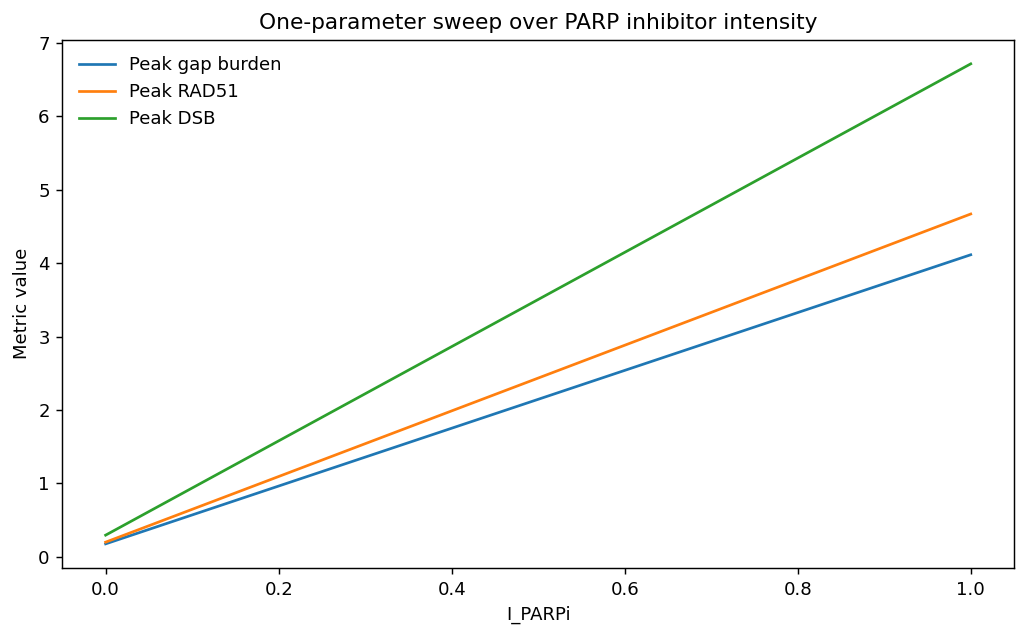

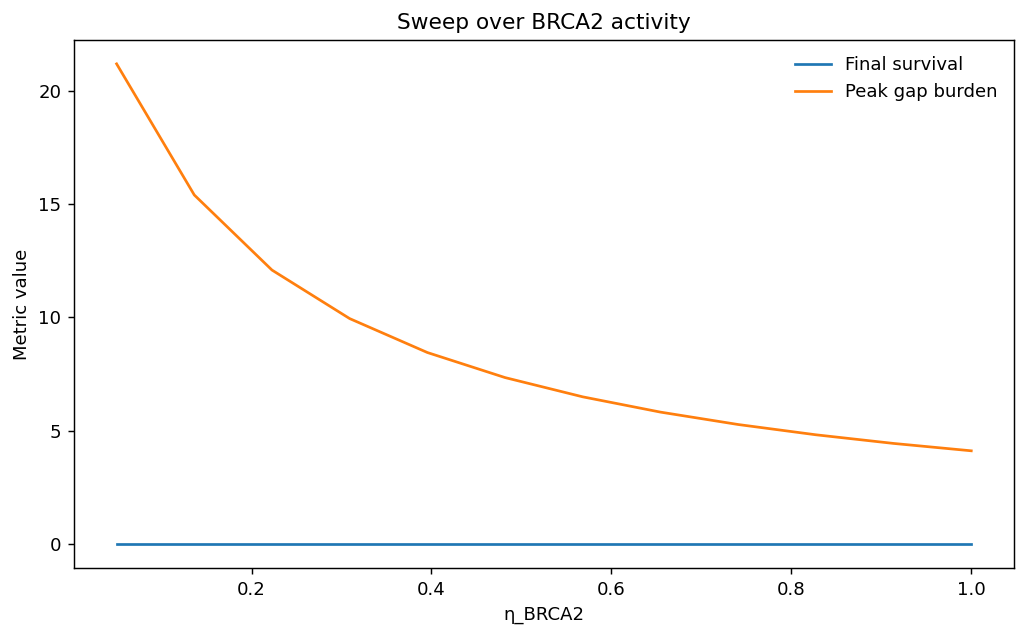

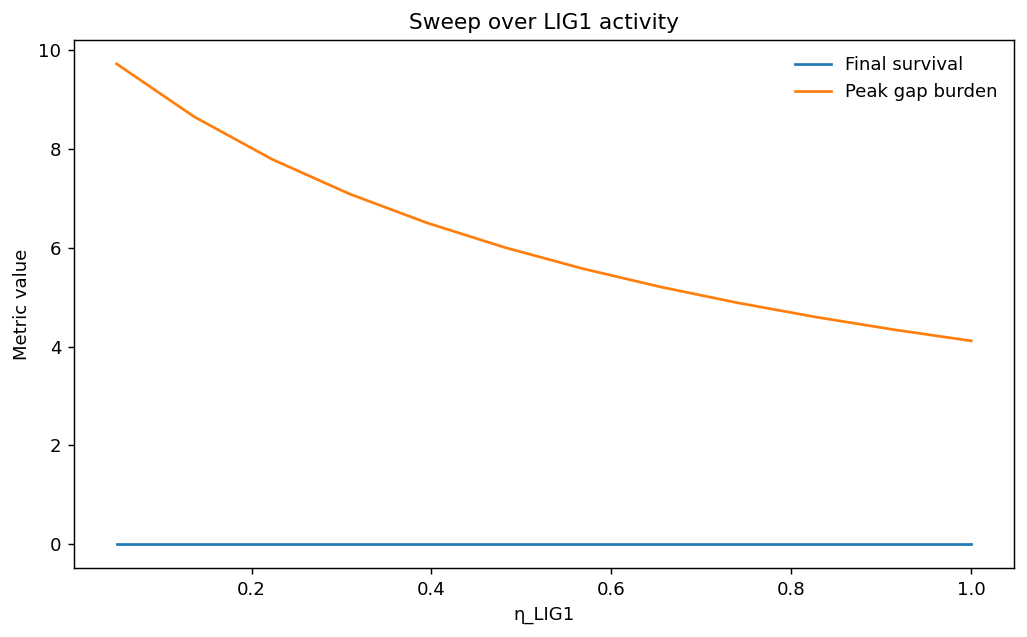

In [76]:

plt.figure(figsize=(8, 5))
plt.plot(sweep_I["value"], sweep_I["gap_peak"], label="Peak gap burden")
plt.plot(sweep_I["value"], sweep_I["rad51_peak"], label="Peak RAD51")
plt.plot(sweep_I["value"], sweep_I["dsb_peak"], label="Peak DSB")
plt.xlabel("I_PARPi")
plt.ylabel("Metric value")
plt.title("One-parameter sweep over PARP inhibitor intensity")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(sweep_BRCA2["value"], sweep_BRCA2["survival_final"], label="Final survival")
plt.plot(sweep_BRCA2["value"], sweep_BRCA2["gap_peak"], label="Peak gap burden")
plt.xlabel("η_BRCA2")
plt.ylabel("Metric value")
plt.title("Sweep over BRCA2 activity")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(sweep_LIG1["value"], sweep_LIG1["survival_final"], label="Final survival")
plt.plot(sweep_LIG1["value"], sweep_LIG1["gap_peak"], label="Peak gap burden")
plt.xlabel("η_LIG1")
plt.ylabel("Metric value")
plt.title("Sweep over LIG1 activity")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


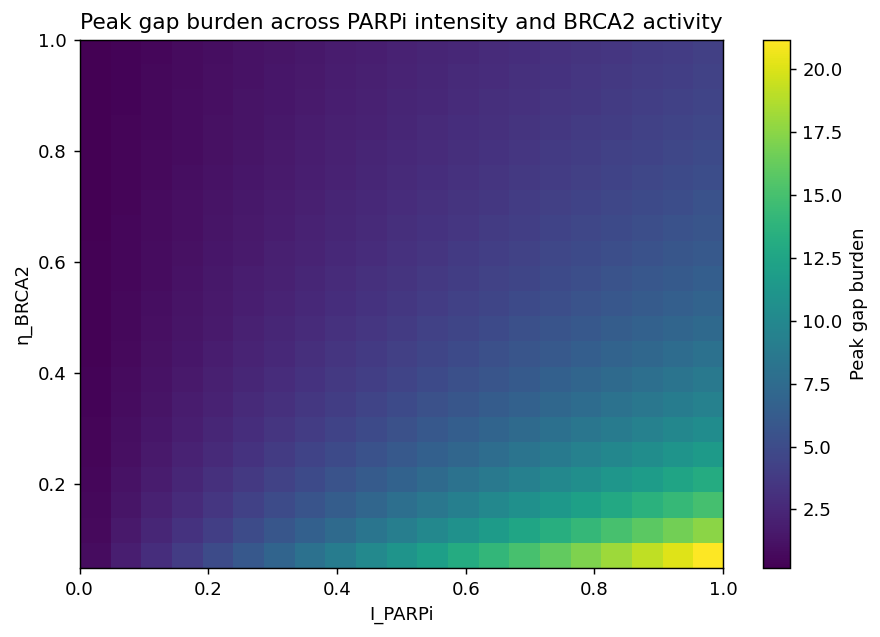

In [78]:

grid_gap = sweep_two_parameters(
    "I_PARPi", np.linspace(0, 1, 21),
    "eta_BRCA2", np.linspace(0.05, 1.0, 21),
    base_for_sweep,
    metric="gap_peak",
)

plot_heatmap(
    grid_gap,
    np.linspace(0, 1, 21),
    np.linspace(0.05, 1.0, 21),
    "I_PARPi",
    "η_BRCA2",
    "Peak gap burden across PARPi intensity and BRCA2 activity",
    "Peak gap burden",
)



## Extension 4. Local sensitivity analysis for β₂, γ, and κ

This section evaluates the effect of perturbing key parameters that control gap formation from trapped complexes (**β₂**), BRCA-dependent rescue (**γ**), and conversion of gaps into DSBs (**κ**).


In [80]:

base_for_sensitivity = dict(common)
base_for_sensitivity.update({
    "eta_LIG1": 1.0,
    "eta_BRCA1": 1.0,
    "eta_BRCA2": 0.3,
    "I_PARPi": 1.0,
    "tau": 1.0,
})

sens_gap = local_sensitivity(base_for_sensitivity, metric="gap_peak")
sens_survival = local_sensitivity(base_for_sensitivity, metric="survival_final")

display(sens_gap)
display(sens_survival)


,parameter,direction,value,metric,baseline,new_value,delta,relative_delta
0,beta2,down,0.71250,gap_peak,10.132323,7.705852,-2.426471,-0.239478
1,beta2,up,1.18750,gap_peak,10.132323,12.558794,2.426471,0.239478
2,gamma,down,0.31500,gap_peak,10.132323,12.015104,1.882781,0.185819
3,gamma,up,0.52500,gap_peak,10.132323,8.759586,-1.372737,-0.135481
4,kappa,down,0.03375,gap_peak,10.132323,10.733018,0.600695,0.059285
5,kappa,up,0.05625,gap_peak,10.132323,9.595292,-0.537032,-0.053002


,parameter,direction,value,metric,baseline,new_value,delta,relative_delta
0,beta2,down,0.71250,survival_final,2.724365e-18,4.179256e-14,4.178984e-14,15339.294815
1,beta2,up,1.18750,survival_final,2.724365e-18,1.775954e-22,-2.724188e-18,-0.999935
2,gamma,down,0.31500,survival_final,2.724365e-18,4.343418e-21,-2.720022e-18,-0.998406
3,gamma,up,0.52500,survival_final,2.724365e-18,3.655017e-16,3.627773e-16,133.160322
4,kappa,down,0.03375,survival_final,2.724365e-18,4.771891e-15,4.769167e-15,1750.560877
5,kappa,up,0.05625,survival_final,2.724365e-18,3.124007e-21,-2.721241e-18,-0.998853


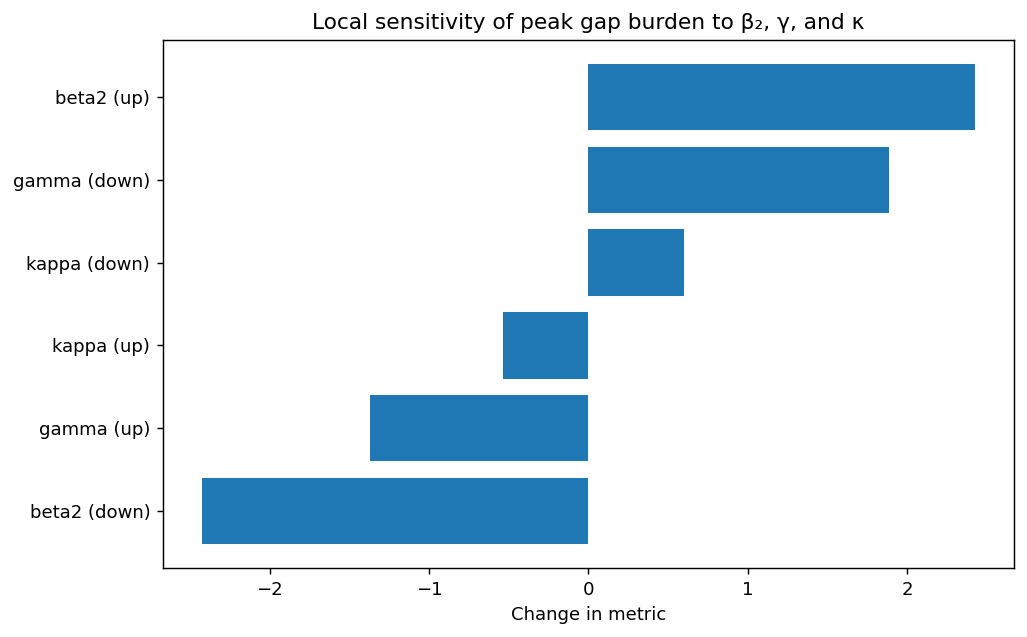

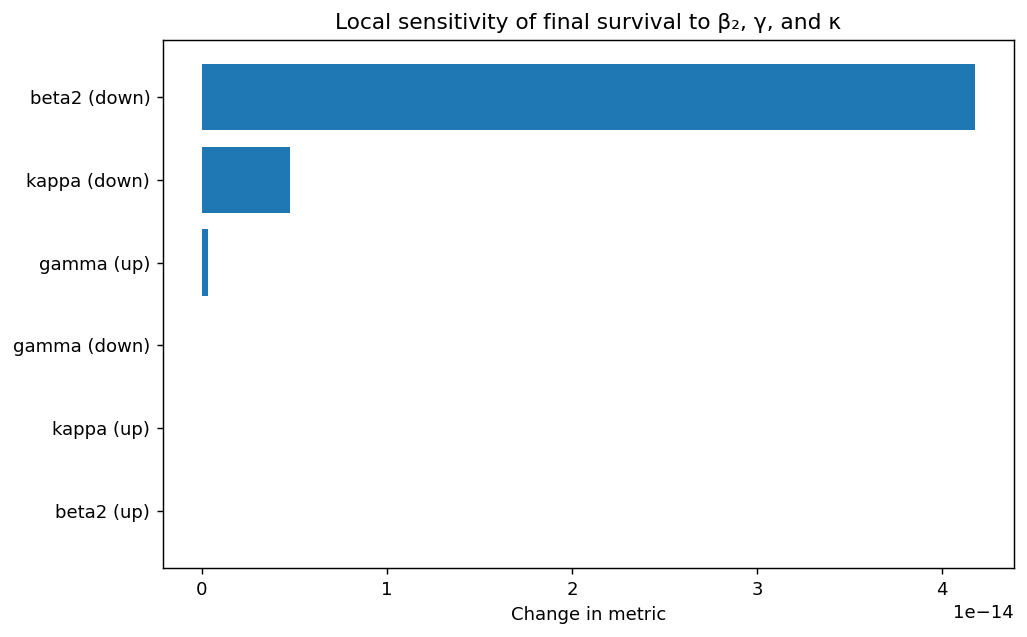

In [81]:

plot_tornado(sens_gap, "Local sensitivity of peak gap burden to β₂, γ, and κ")
plot_tornado(sens_survival, "Local sensitivity of final survival to β₂, γ, and κ")



## Extension 5. Stochastic lesion formation instead of deterministic inflow

The deterministic model uses a constant lesion inflow term. The stochastic extension below replaces this with a noisy inflow term, allowing cell-to-cell or time-varying heterogeneity in the generation of replication-associated lesions.


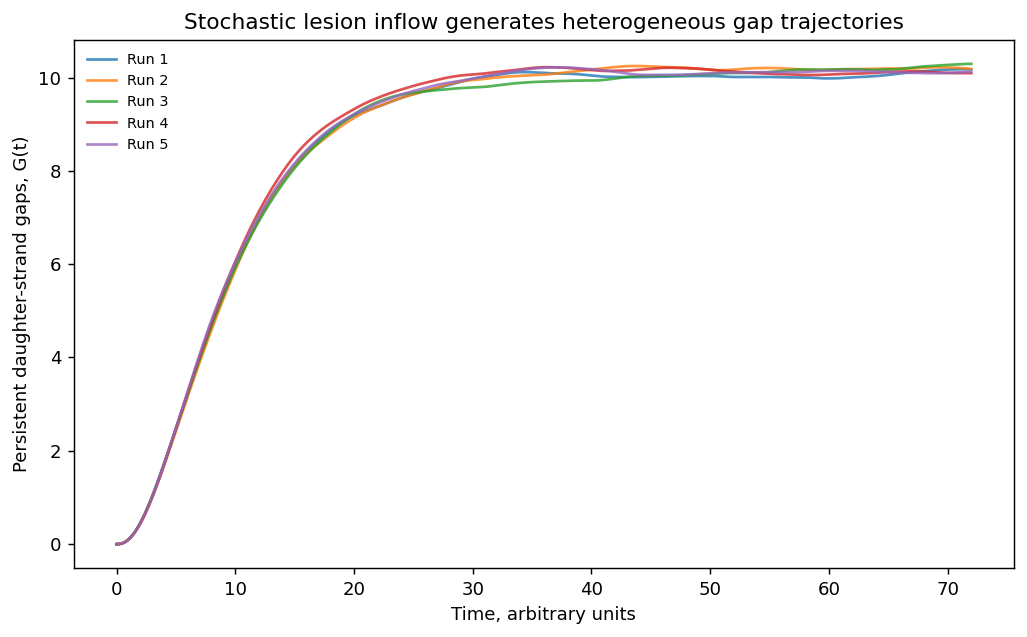

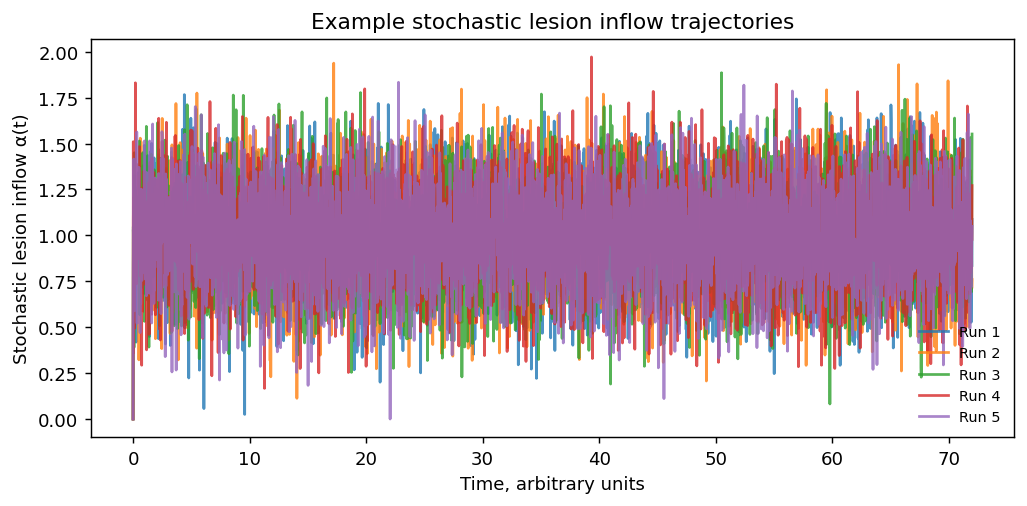

In [83]:

stoch_kwargs = dict(common)
stoch_kwargs.update({
    "eta_LIG1": 1.0,
    "eta_BRCA1": 1.0,
    "eta_BRCA2": 0.3,
    "I_PARPi": 1.0,
    "tau": 1.0,
})

stoch_runs = [simulate_condition_stochastic(alpha_mean=1.0, alpha_noise=0.25, seed=s, **stoch_kwargs) for s in range(5)]

plt.figure(figsize=(8, 5))
for i, res in enumerate(stoch_runs):
    plt.plot(res["t"], res["G"], alpha=0.8, label=f"Run {i+1}")
plt.xlabel("Time, arbitrary units")
plt.ylabel("Persistent daughter-strand gaps, G(t)")
plt.title("Stochastic lesion inflow generates heterogeneous gap trajectories")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
for i, res in enumerate(stoch_runs):
    plt.plot(res["t"], res["alpha_series"], alpha=0.8, label=f"Run {i+1}")
plt.xlabel("Time, arbitrary units")
plt.ylabel("Stochastic lesion inflow α(t)")
plt.title("Example stochastic lesion inflow trajectories")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()



## Extension 6. Explicit fork-proximal and fork-distal compartments

The original reduced model treats the lesion burden as a single compartment. The extension below separates replication-associated lesions into:

- **fork-proximal** states, representing newly generated or near-fork intermediates
- **fork-distal** states, representing post-replicative lesions that have persisted or been transferred farther behind the fork

This split allows exploration of the idea that PARP-linked maturation defects can begin near forks but become biologically consequential at more distal post-replicative daughter-strand gaps.


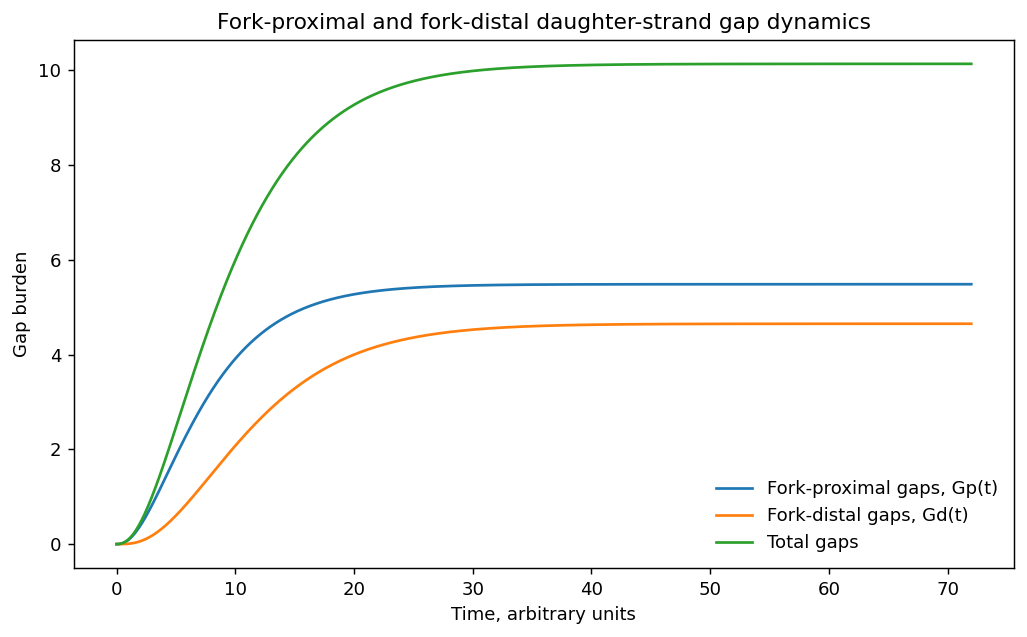

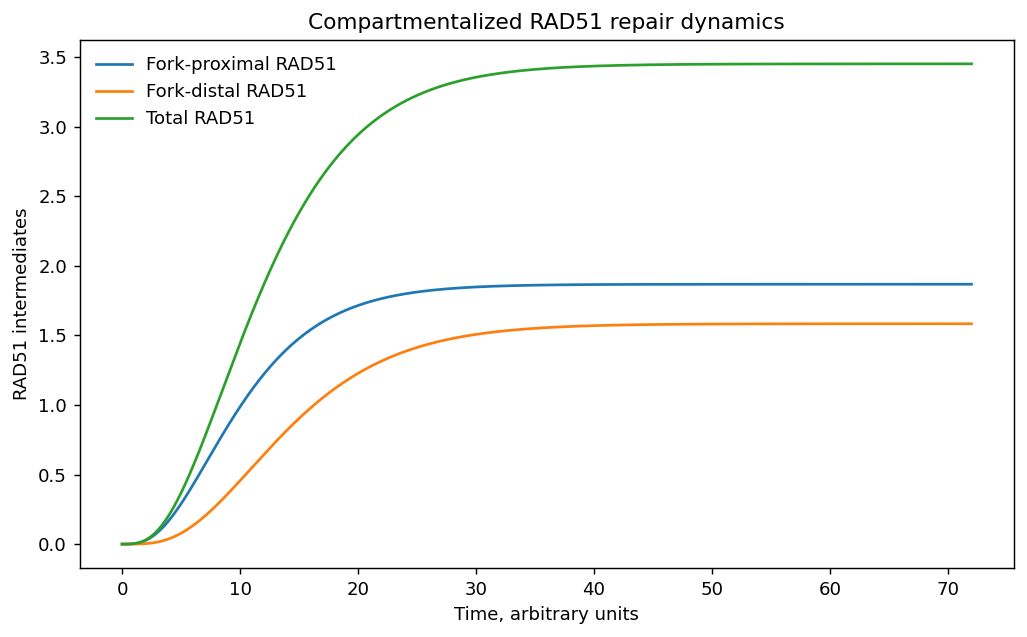

In [89]:

comp_allowed = {
    "t_max",
    "dt",
    "eta_LIG1",
    "eta_BRCA1",
    "eta_BRCA2",
    "I_PARPi",
    "k_lig",
    "k_p",
    "k_trap_max",
    "tau",
    "delta_T",
    "beta1",
    "beta2",
    "gamma",
    "kappa",
    "delta_G",
    "rho",
    "delta_R",
    "delta_D",
    "omega_G",
    "omega_D",
}

comp_kwargs = {k: v for k, v in common.items() if k in comp_allowed}
comp_kwargs["alpha_p"] = common.get("alpha", 1.0)

comp_kwargs.update({
    "eta_LIG1": 1.0,
    "eta_BRCA1": 1.0,
    "eta_BRCA2": 0.3,
    "I_PARPi": 1.0,
    "tau": 1.0,
})

comp = simulate_condition_compartmental(**comp_kwargs)

plt.figure(figsize=(8, 5))
plt.plot(comp["t"], comp["Gp"], label="Fork-proximal gaps, Gp(t)")
plt.plot(comp["t"], comp["Gd"], label="Fork-distal gaps, Gd(t)")
plt.plot(comp["t"], comp["G_total"], label="Total gaps")
plt.xlabel("Time, arbitrary units")
plt.ylabel("Gap burden")
plt.title("Fork-proximal and fork-distal daughter-strand gap dynamics")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(comp["t"], comp["Rp"], label="Fork-proximal RAD51")
plt.plot(comp["t"], comp["Rd"], label="Fork-distal RAD51")
plt.plot(comp["t"], comp["R_total"], label="Total RAD51")
plt.xlabel("Time, arbitrary units")
plt.ylabel("RAD51 intermediates")
plt.title("Compartmentalized RAD51 repair dynamics")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



## Extension 7. Fitting to synthetic comet assay, DNA combing, and RAD51-foci-like datasets

This section creates assay-like synthetic observations and then fits **β₂**, **γ**, and **κ** to those synthetic datasets.

The assay emulators are intentionally simple:

- **comet tail moment** increases with gap burden and, to a lesser extent, DSB burden
- **DNA combing IdU tract length** decreases as gap burden rises
- **RAD51 foci** increase with modeled RAD51 intermediate burden

These are **synthetic observables**, meant to mimic the qualitative directionality of assays used in the PARP and replication-gap literature rather than exact assay calibration.


In [92]:

target_kwargs = dict(common)
target_kwargs.update({
    "eta_LIG1": 1.0,
    "eta_BRCA1": 1.0,
    "eta_BRCA2": 0.25,
    "I_PARPi": 1.0,
    "tau": 1.0,
    "beta2": 1.05,
    "gamma": 0.38,
    "kappa": 0.05,
})

target_times = [4, 8, 12, 24, 36, 48, 60]
target_df = generate_synthetic_assay_dataset(target_kwargs, target_times, noise_frac=0.06, seed=321)
display(target_df)


,time,comet_tail_moment,combing_IdU_length,RAD51_foci
0,4,2.270166,23.267057,5.945697
1,8,4.518638,17.951261,12.213920
2,12,7.375835,14.162272,20.973102
3,24,10.004418,10.941658,30.092318
4,36,11.624454,9.933641,32.761025
5,48,12.722171,9.839515,31.900165
6,60,12.828709,9.431406,36.265367


In [94]:

fit_fixed = dict(common)
fit_fixed.update({
    "eta_LIG1": 1.0,
    "eta_BRCA1": 1.0,
    "eta_BRCA2": 0.25,
    "I_PARPi": 1.0,
    "tau": 1.0,
})

fit_trials = random_search_fit(fit_fixed, target_df, n_iter=300, seed=222)
best_fit = fit_trials.iloc[0]
display(fit_trials.head(10))
best_fit


,beta2,gamma,kappa,mse
0,1.164565,0.363771,0.061880,3.854076
1,1.102803,0.440696,0.054913,4.974414
2,1.187184,0.458476,0.085851,5.289933
3,1.234548,0.450523,0.083692,5.593533
4,1.208771,0.468316,0.088326,6.146050
5,1.167016,0.449459,0.091700,6.470641
6,1.284215,0.399368,0.109259,7.437656
7,1.331381,0.356284,0.094925,7.850313
8,1.055530,0.357135,0.029063,9.719423
9,0.924363,0.378744,0.044265,10.502941


beta2    1.164565
gamma    0.363771
kappa    0.061880
mse      3.854076
Name: 0, dtype: float64

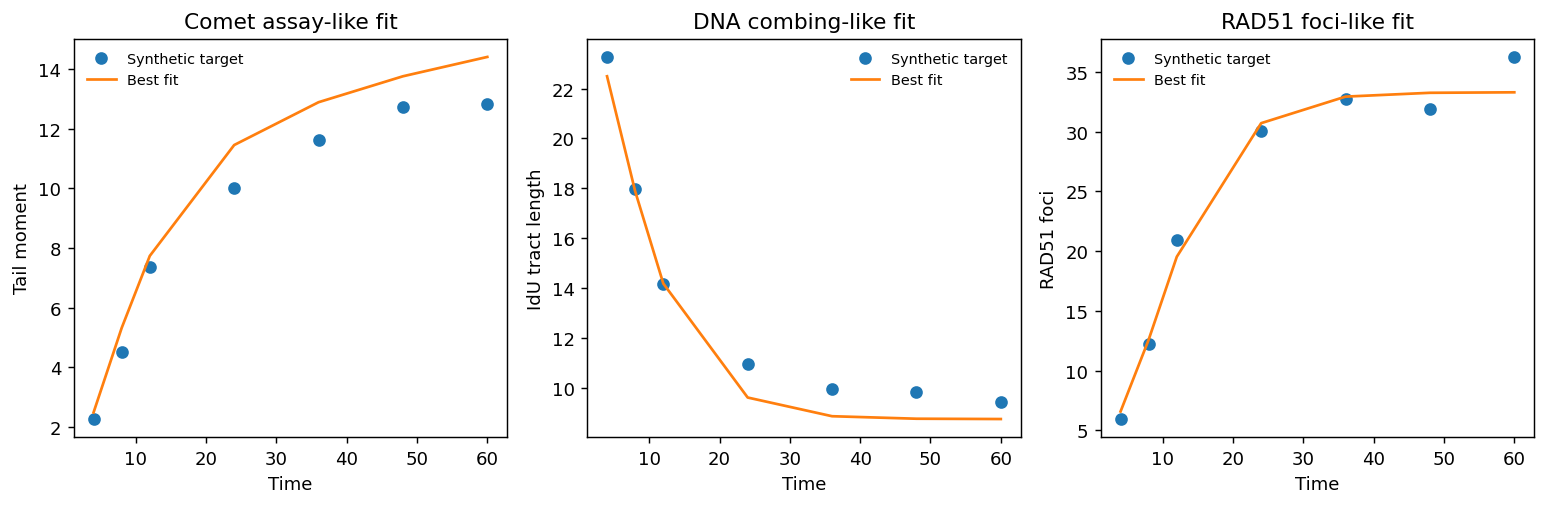

In [95]:

best_kwargs = dict(fit_fixed)
best_kwargs["beta2"] = float(best_fit["beta2"])
best_kwargs["gamma"] = float(best_fit["gamma"])
best_kwargs["kappa"] = float(best_fit["kappa"])

fitted_df = generate_synthetic_assay_dataset(best_kwargs, target_times, noise_frac=0.0, seed=999)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(target_df["time"], target_df["comet_tail_moment"], "o", label="Synthetic target")
axes[0].plot(fitted_df["time"], fitted_df["comet_tail_moment"], "-", label="Best fit")
axes[0].set_title("Comet assay-like fit")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Tail moment")

axes[1].plot(target_df["time"], target_df["combing_IdU_length"], "o", label="Synthetic target")
axes[1].plot(fitted_df["time"], fitted_df["combing_IdU_length"], "-", label="Best fit")
axes[1].set_title("DNA combing-like fit")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("IdU tract length")

axes[2].plot(target_df["time"], target_df["RAD51_foci"], "o", label="Synthetic target")
axes[2].plot(fitted_df["time"], fitted_df["RAD51_foci"], "-", label="Best fit")
axes[2].set_title("RAD51 foci-like fit")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("RAD51 foci")

for ax in axes:
    ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()



## Extension 8. Interpretation of the notebook extensions

These additions broaden the original proof-of-concept notebook in five useful directions.

Parameter sweeps make it possible to visualize phase-like transitions as PARP inhibitor intensity rises, or as BRCA2 and LIG1 function are lost. Sensitivity analysis identifies which mechanistic parameters are most influential for gap burden or survival. The stochastic lesion model shows how heterogeneity in lesion inflow can broaden phenotype distributions even when the mean parameter set is unchanged. The compartmental model separates fork-proximal and fork-distal lesions, which is useful when considering the distinction between newly formed replication intermediates and persistent post-replicative daughter-strand gaps. Finally, the synthetic assay-fitting block provides a scaffold for replacing toy observables with real comet assay, DNA combing, or RAD51-foci time courses in future data-integrated versions of the model.
